In [ ]:
# Importing Lib
import pandas as pd
import numpy as np


In [ ]:
dataset = pd.read_csv("twitter_data (1).csv")

In [ ]:
dataset

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an..."
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies


In [ ]:
dataset.isnull()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
24778,False,False,False,False,False,False,False
24779,False,False,False,False,False,False,False
24780,False,False,False,False,False,False,False
24781,False,False,False,False,False,False,False


In [ ]:
dataset.isnull().sum()

,0
Unnamed: 0,0
count,0
hate_speech,0
offensive_language,0
neither,0
class,0
tweet,0


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB


In [ ]:
dataset.describe()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class
count,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000
mean,12681.192027,3.243473,0.280515,2.413711,0.549247,1.110277
std,7299.553863,0.883060,0.631851,1.399459,1.113299,0.462089
min,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,6372.500000,3.000000,0.000000,2.000000,0.000000,1.000000
50%,12703.000000,3.000000,0.000000,3.000000,0.000000,1.000000
75%,18995.500000,3.000000,0.000000,3.000000,0.000000,1.000000
max,25296.000000,9.000000,7.000000,9.000000,9.000000,2.000000


In [ ]:
dataset["lables"] = dataset["class"].map({0:"Hate Speech",
                                          1:"Offensive Language",
                                          2:"No hate or offensive language"})

In [ ]:
dataset

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,lables
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,No hate or offensive language
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language
...,...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...,Offensive Language
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an...",No hate or offensive language
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...,Offensive Language
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies,Offensive Language


In [ ]:
data = dataset[["tweet","lables"]]

In [ ]:
data

,tweet,lables
0,!!! RT @mayasolovely: As a woman you shouldn't...,No hate or offensive language
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language
...,...,...
24778,you's a muthaf***in lie &#8220;@LifeAsKing: @2...,Offensive Language
24779,"you've gone and broke the wrong heart baby, an...",No hate or offensive language
24780,young buck wanna eat!!.. dat nigguh like I ain...,Offensive Language
24781,youu got wild bitches tellin you lies,Offensive Language


In [ ]:
import re
import nltk
import string

In [ ]:
!pip install opencv-python

In [ ]:
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# Importing stop words
from nltk.corpus import stopwords
stopwords = set(stopwords.words("english"))


In [ ]:
# import stemming
stemmer = nltk.SnowballStemmer("english")

In [ ]:
# Data Cleaning Function
def clean_data(text):
    text = str(text).lower()


    text = re.sub(r'https?://\S+|www\.\S+', '', text)


    text = re.sub(r'\[.*?\]', '', text)


    text = re.sub(r'<.*?>+', '', text)


    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)


    text = re.sub(r'\n', '', text)


    text = re.sub(r'\w*\d\w*', '', text)


    text = [word for word in text.split() if word not in stopwords]
    text = " ".join(text)


    text = [stemmer.stem(word) for word in text.split()]
    text = " ".join(text)

    return text





In [ ]:
data["tweet"] = data["tweet"].apply(clean_data)

/tmp/ipykernel_1241/1832165696.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["tweet"] = data["tweet"].apply(clean_data)


In [ ]:
data

,tweet,lables
0,rt mayasolov woman shouldnt complain clean hou...,No hate or offensive language
1,rt boy dat coldtyga dwn bad cuffin dat hoe place,Offensive Language
2,rt urkindofbrand dawg rt ever fuck bitch start...,Offensive Language
3,rt cganderson vivabas look like tranni,Offensive Language
4,rt shenikarobert shit hear might true might fa...,Offensive Language
...,...,...
24778,yous muthafin lie coreyemanuel right tl trash ...,Offensive Language
24779,youv gone broke wrong heart babi drove redneck...,No hate or offensive language
24780,young buck wanna eat dat nigguh like aint fuck...,Offensive Language
24781,youu got wild bitch tellin lie,Offensive Language


In [ ]:
x = np.array(data["tweet"])
y = np.array(data["lables"])

In [ ]:
x

array(['rt mayasolov woman shouldnt complain clean hous amp man alway take trash',
       'rt boy dat coldtyga dwn bad cuffin dat hoe place',
       'rt urkindofbrand dawg rt ever fuck bitch start cri confus shit',
       ..., 'young buck wanna eat dat nigguh like aint fuckin dis',
       'youu got wild bitch tellin lie',
       'ruffl ntac eileen dahlia beauti color combin pink orang yellow amp white coll'],
      dtype=object)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

In [ ]:
cv = CountVectorizer()
x = cv.fit_transform(x)

In [ ]:
x

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 197854 stored elements and shape (24783, 25693)>

In [ ]:
x_train, x_test, y_train, y_test  = train_test_split(x,y, test_size=0.33, random_state=42)

In [ ]:
x_train

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 132612 stored elements and shape (16604, 25693)>

In [ ]:
#Building out ML Model
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = dt.predict(x_test)

In [ ]:
# confusion matrix and accuracy
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm


array([[ 153,   31,  281],
       [  31, 1131,  217],
       [ 211,  226, 5898]])

In [ ]:
import seaborn as sns
import matplotlib.pyplot as ply
%matplotlib inline

<Axes: >

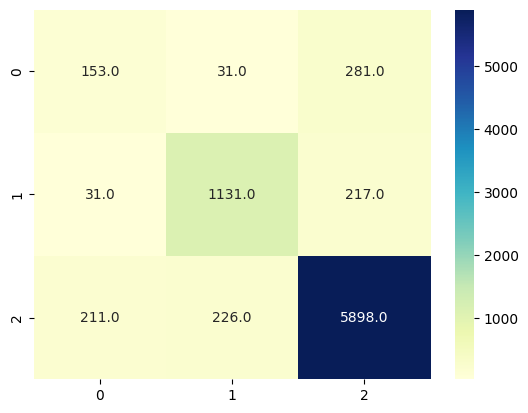

In [ ]:
sns.heatmap(cm, annot = True, fmt=".1f", cmap="YlGnBu")

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8781024575131434

In [ ]:
sample = "Let's unite and kill all the people who are protesting against the government"
sample = clean_data(sample)

In [ ]:
sample

'let unit kill peopl protest govern'

In [ ]:
data1 = cv.transform([sample]).toarray()

In [ ]:
data1

array([[0, 0, 0, ..., 0, 0, 0]])

In [ ]:
dt.predict(data1)

array(['Hate Speech'], dtype=object)

In [ ]:
!pip install streamlit pandas numpy scikit-learn nltk pickle-mixin

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 96.4 MB/s eta 0:00:00
  Created wheel for pickle-mixin: filename=pickle_mixin-1.0.2-py3-none-any.whl size=5988 sha256=12689cda510296375696c741e3cabb428afec3e6b05f2ef8eb872c04b916fb05
  Stored in directory: /root/.cache/pip/wheels/69/e2/5c/da8f96a08c63469bc8b10e206cd4c78e8886d8acb8699f84c2
Successfully built pickle-mixin


In [ ]:
import pickle

pickle.dump(dt, open("model.pkl", "wb"))
pickle.dump(cv, open("vectorizer.pkl", "wb"))

In [2]:
app_code = '''
import streamlit as st
import pickle
import re
import nltk
import string
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))
stemmer = nltk.SnowballStemmer("english")

def clean_data(text):
    text = str(text).lower()
    text = re.sub(r'https?://\\S+|www\\.\\S+', '', text)
    text = re.sub(r'\\[.*?\\]', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\\n', '', text)
    text = re.sub(r'\\w*\\d\\w*', '', text)

    text = [word for word in text.split() if word not in stop_words]
    text = " ".join(text)

    text = [stemmer.stem(word) for word in text.split()]
    text = " ".join(text)

    return text

model = pickle.load(open("model.pkl", "rb"))
cv = pickle.load(open("vectorizer.pkl", "rb"))

st.title("Twitter Hate Speech Detection")

user_input = st.text_area("Enter Tweet")

if st.button("Predict"):
    cleaned = clean_data(user_input)
    vector = cv.transform([cleaned]).toarray()
    result = model.predict(vector)

    st.success(f"Prediction: {result[0]}")
'''

with open("app.py", "w") as file:
    file.write(app_code)

print("app.py created successfully")

app.py created successfully


In [ ]:
!streamlit run app.py



2026-05-16 16:18:59.888 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.117.220.138:8501



In [ ]:
requirements = '''
streamlit
pandas
numpy
scikit-learn
nltk
pickle-mixin
'''

with open("requirements.txt", "w") as file:
    file.write(requirements)

print("requirements.txt created successfully")